# Data Verification: Sweep Delay

This notebook validates sweep alignment using the deconvolution method:

`H = Y * conj(X) / (abs(X)**2 + reg)`

The main path uses the full recorded sweep pair. Active-window trimming is included only as a diagnostic comparison, because trimming the excitation changes the deconvolution problem and can move the impulse-response peak.

In [1]:
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)

PAIR_RE = re.compile(r"seq(?P<seq>\d+).*?_level_minus(?P<level>[\d.]+)dB_meas(?P<meas>\d+)")
INPUT_SUFFIXES = ("_input_aligned", "_loopback", "_recorded_sweep", "_recorded_sweep_trimmed")
TARGET_SUFFIXES = ("_target_aligned", "_mic", "_mic_aligned_trimmed")

In [16]:
@dataclass(frozen=True)
class Pair:
    key: str
    seq: int
    meas: int
    level_db: float
    loopback_path: Path
    mic_path: Path


@dataclass(frozen=True)
class ActiveRegion:
    start_sample: int
    end_sample: int
    threshold_db: float
    margin_samples: int

    @property
    def length_samples(self) -> int:
        return self.end_sample - self.start_sample


@dataclass
class SweepDelayResult:
    pair: Pair
    method: str
    sample_rate: int
    region: ActiveRegion | None
    delay_samples: int
    peak_value: float
    impulse_response: np.ndarray

    @property
    def delay_ms(self) -> float:
        return 1000 * self.delay_samples / self.sample_rate

    @property
    def summary(self) -> dict:
        return {
            "key": self.pair.key,
            "method": self.method,
            "level_db": self.pair.level_db,
            "delay_samples": self.delay_samples,
            "delay_ms": round(self.delay_ms, 3),
            "peak_value": round(float(self.peak_value), 6),
            "region_start": None if self.region is None else self.region.start_sample,
            "region_end": None if self.region is None else self.region.end_sample,
        }


def _pair_base_and_role(file_path: Path) -> tuple[str, str] | None:
    stem = file_path.stem
    for suffix in INPUT_SUFFIXES:
        if stem.endswith(suffix):
            return stem[: -len(suffix)], "input"
    for suffix in TARGET_SUFFIXES:
        if stem.endswith(suffix):
            return stem[: -len(suffix)], "target"
    return None


def find_pairs(path: str | Path, selection_db: list[float] | None = None) -> list[Pair]:
    groups = defaultdict(dict)
    for file_path in sorted(Path(path).glob("*.wav")):
        parsed = _pair_base_and_role(file_path)
        if parsed is None:
            continue
        base, role = parsed
        groups[base][role] = file_path

    pairs = []
    for base, files in sorted(groups.items()):
        if "input" not in files or "target" not in files:
            continue
        match = PAIR_RE.search(base)
        if match is None:
            continue
        level_db = -float(match.group("level"))
        if selection_db is not None and not any(np.isclose(level_db, selected) for selected in selection_db):
            continue
        pairs.append(
            Pair(
                key=base,
                seq=int(match.group("seq")),
                meas=int(match.group("meas")),
                level_db=level_db,
                loopback_path=files["input"],
                mic_path=files["target"],
            )
        )
    return pairs


def load_mono(path: str | Path) -> tuple[np.ndarray, int]:
    data, sample_rate = sf.read(str(path), dtype="float32", always_2d=False)
    if data.ndim > 1:
        data = np.mean(data, axis=1)
    return np.asarray(data, dtype=np.float32), int(sample_rate)

def load_pair(pair: Pair) -> tuple[np.ndarray, np.ndarray, int]:
    x, sr_x = load_mono(pair.loopback_path)
    y, sr_y = load_mono(pair.mic_path)
    if sr_x != sr_y:
        raise ValueError(f"Sample rates do not match: {sr_x} vs {sr_y}")
    return x, y, sr_x

In [3]:
def next_power_of_two(value: int) -> int:
    return 1 << (value - 1).bit_length()


def estimate_ir_from_sweep(
    reference_sweep: np.ndarray,
    measured_output: np.ndarray,
    reg: float = 1e-8,
    n_fft: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate impulse response using regularized spectral division."""
    n = len(reference_sweep) + len(measured_output) - 1
    if n_fft is None or n_fft < n:
        n_fft = next_power_of_two(n)

    X = np.fft.rfft(reference_sweep, n=n_fft)
    Y = np.fft.rfft(measured_output, n=n_fft)
    H = Y * np.conj(X) / (np.abs(X) ** 2 + reg)
    h = np.fft.irfft(H, n=n_fft)
    return h, H


def estimate_delay_from_ir(
    impulse_response: np.ndarray,
    sample_rate: int,
    search_start_s: float = 0.0,
    search_end_s: float = 1.0,
) -> dict:
    start = int(search_start_s * sample_rate)
    end = min(int(search_end_s * sample_rate), len(impulse_response))
    if end <= start:
        raise ValueError("Impulse-response search window is empty.")

    segment = impulse_response[start:end]
    peak = int(np.argmax(np.abs(segment)) + start)
    return {
        "delay_samples": peak,
        "delay_seconds": peak / sample_rate,
        "delay_ms": 1000 * peak / sample_rate,
        "peak_value": float(impulse_response[peak]),
    }


def estimate_sweep_delay(
    pair: Pair,
    reg: float = 1e-8,
    search_start_s: float = 0.0,
    search_end_s: float = 1.0,
    region: ActiveRegion | None = None,
) -> SweepDelayResult:
    x, sample_rate = load_mono(pair.loopback_path)
    y, target_sample_rate = load_mono(pair.mic_path)
    if sample_rate != target_sample_rate:
        raise ValueError("Input and target sample rates do not match.")

    if region is not None:
        x = x[region.start_sample : region.end_sample]
        y = y[region.start_sample : region.end_sample]

    h, _ = estimate_ir_from_sweep(x, y, reg=reg)
    delay = estimate_delay_from_ir(h, sample_rate, search_start_s, search_end_s)
    method = "sweep_deconvolution" if region is None else "sweep_deconvolution_active_window"
    return SweepDelayResult(
        pair=pair,
        method=method,
        sample_rate=sample_rate,
        region=region,
        delay_samples=delay["delay_samples"],
        peak_value=delay["peak_value"],
        impulse_response=h,
    )

In [4]:
def rms_envelope(signal: np.ndarray, sample_rate: int, frame_ms: float = 10.0, hop_ms: float = 2.5):
    frame = max(1, int(round(frame_ms * sample_rate / 1000)))
    hop = max(1, int(round(hop_ms * sample_rate / 1000)))
    if len(signal) < frame:
        return np.array([0]), np.array([float(np.sqrt(np.mean(signal.astype(np.float64) ** 2)))])

    starts = np.arange(0, len(signal) - frame + 1, hop)
    envelope = np.array([
        np.sqrt(np.mean(signal[start : start + frame].astype(np.float64) ** 2))
        for start in starts
    ])
    return starts, envelope


def find_active_region_from_loopback(
    loopback_signal: np.ndarray,
    sample_rate: int,
    threshold_db: float = -50.0,
    frame_ms: float = 10.0,
    hop_ms: float = 2.5,
    margin_ms: float = 50.0,
) -> ActiveRegion:
    starts, envelope = rms_envelope(loopback_signal, sample_rate, frame_ms, hop_ms)
    peak = np.max(envelope)
    if peak <= 0:
        return ActiveRegion(0, len(loopback_signal), threshold_db, 0)

    envelope_db = 20 * np.log10(np.maximum(envelope, 1e-12) / peak)
    active = np.where(envelope_db >= threshold_db)[0]
    if active.size == 0:
        return ActiveRegion(0, len(loopback_signal), threshold_db, 0)

    margin = int(round(margin_ms * sample_rate / 1000))
    frame = max(1, int(round(frame_ms * sample_rate / 1000)))
    start = max(0, int(starts[active[0]]) - margin)
    end = min(len(loopback_signal), int(starts[active[-1]]) + frame + margin)
    return ActiveRegion(start, end, threshold_db, margin)


def estimate_active_region(pair: Pair, threshold_db: float = -50.0, margin_ms: float = 50.0) -> ActiveRegion:
    x, sample_rate = load_mono(pair.loopback_path)
    return find_active_region_from_loopback(x, sample_rate, threshold_db=threshold_db, margin_ms=margin_ms)


def compare_full_and_active_window(
    pair: Pair,
    threshold_db: float = -50.0,
    margin_ms: float = 50.0,
    search_end_s: float = 1.0,
) -> tuple[pd.DataFrame, list[SweepDelayResult]]:
    region = estimate_active_region(pair, threshold_db=threshold_db, margin_ms=margin_ms)
    results = [
        estimate_sweep_delay(pair, search_end_s=search_end_s),
        estimate_sweep_delay(pair, search_end_s=search_end_s, region=region),
    ]
    return pd.DataFrame([result.summary for result in results]), results

In [5]:
def plot_pair_with_region(pair: Pair, region: ActiveRegion | None = None, max_samples: int | None = None):
    x, sample_rate = load_mono(pair.loopback_path)
    y, target_sample_rate = load_mono(pair.mic_path)
    if sample_rate != target_sample_rate:
        raise ValueError("Input and target sample rates do not match.")

    if max_samples is None:
        max_samples = min(len(x), len(y))
    samples = np.arange(max_samples)
    seconds = samples / sample_rate

    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(seconds, x[:max_samples], linewidth=0.8)
    plt.title(f"Loopback / recorded sweep: {pair.key}")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 1, 2)
    plt.plot(seconds, y[:max_samples], linewidth=0.8)
    plt.title("Microphone")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)

    if region is not None:
        for axis in plt.gcf().axes:
            axis.axvline(region.start_sample / sample_rate, color="red", linestyle="--", label="active start")
            axis.axvline(region.end_sample / sample_rate, color="red", linestyle="--", label="active end")
            axis.legend()
    plt.tight_layout()


def plot_impulse_response(result: SweepDelayResult, n_samples: int = 500):
    samples = np.arange(min(n_samples, len(result.impulse_response)))
    plt.figure(figsize=(10, 4))
    plt.plot(samples, result.impulse_response[: len(samples)])
    plt.axvline(result.delay_samples, color="red", linestyle="--", label="delay peak")
    plt.title(f"{result.method}: {result.delay_samples} samples / {result.delay_ms:.3f} ms")
    plt.xlabel("Impulse-response sample")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def plot_phase_response(res: dict, f_min: float = 20.0, f_max: float = 20000.0, gd_ylim=(-10, 20)):
    freqs = res["freqs"]
    valid = res["valid_phase_mask"]
    plot_band = (freqs >= f_min) & (freqs <= f_max)
    valid_band = plot_band & valid

    plt.figure(figsize=(10, 9))

    plt.subplot(3, 1, 1)
    plt.semilogx(freqs[plot_band], res["magnitude_db"][plot_band])
    plt.grid(True, which="both")
    plt.ylabel("Magnitude [dB]")
    plt.title("Direct-response transfer function")

    plt.subplot(3, 1, 2)
    plt.semilogx(freqs[valid_band], res["phase_rad"][valid_band])
    plt.grid(True, which="both")
    plt.ylabel("Unwrapped phase [rad]")

    plt.subplot(3, 1, 3)
    plt.semilogx(freqs[valid_band], res["group_delay_s"][valid_band] * 1000, alpha=0.35, label="raw")
    plt.semilogx(freqs[valid_band], res["group_delay_s_smooth"][valid_band] * 1000, label="smoothed")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylim(*gd_ylim)
    plt.grid(True, which="both")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Group delay [ms]")
    plt.legend()

    plt.tight_layout()

## Example: Inspect One Sweep Pair

Change `PAIR_INDEX`, `SELECTION_DB`, or the folder path to inspect another sweep. The full-signal result is the recommended primary estimate; active-window output is a diagnostic comparison only.

In [11]:
high_sweep = find_pairs(Path("data/raw/raw_sweeps"), selection_db=[-9])[0]
low_sweep = find_pairs(Path("data/raw/raw_sweeps"), selection_db=[-34])[0]

,key,method,level_db,delay_samples,delay_ms,peak_value,region_start,region_end
0,20260424_170351_seq041_level_minus9.0dB_meas01,sweep_deconvolution,-9.0,18,0.375,0.794645,NaN,NaN
1,20260424_170351_seq041_level_minus9.0dB_meas01,sweep_deconvolution_active_window,-9.0,18,0.375,0.810527,7320.0,396120.0


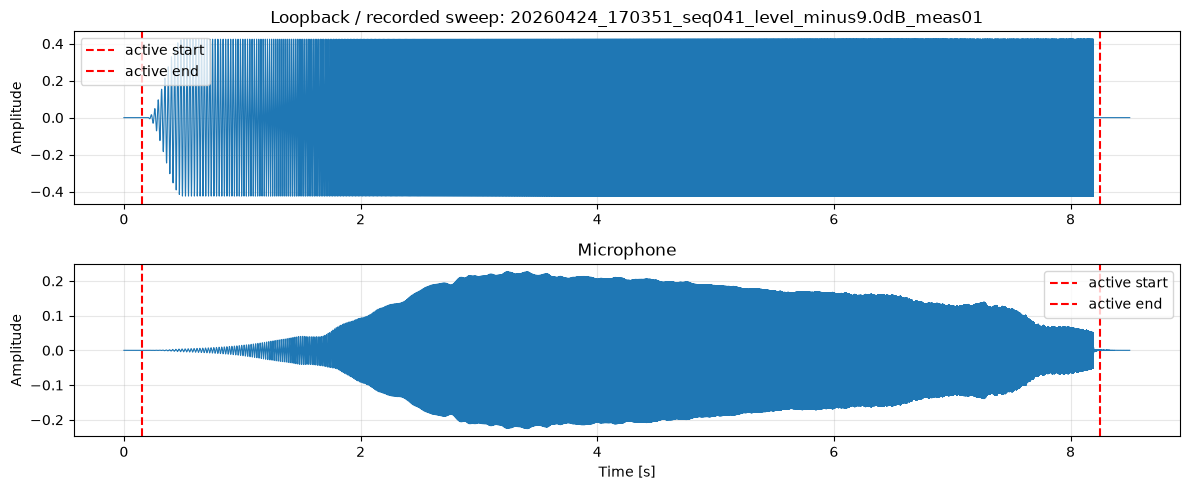

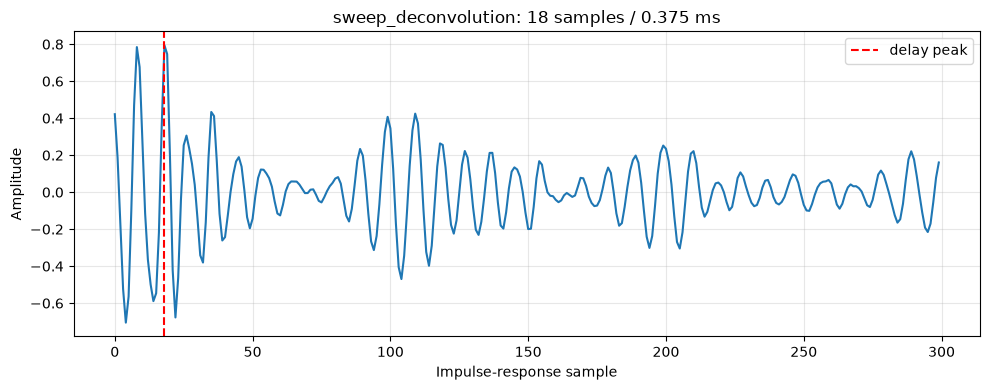

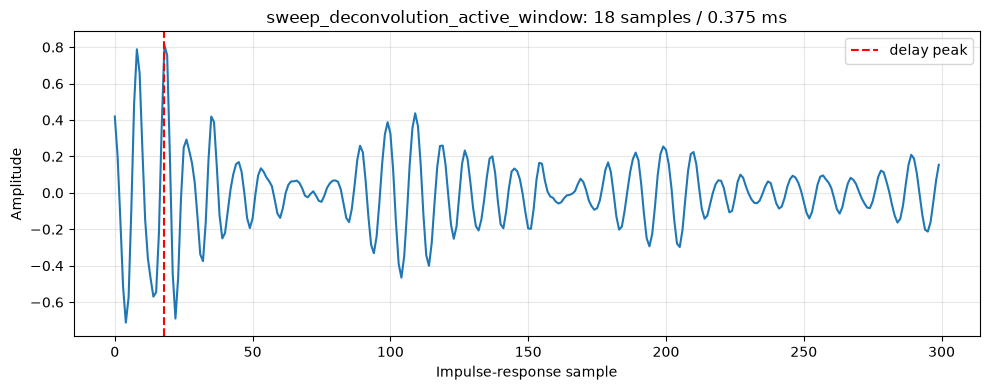

In [6]:
SELECTION_DB = [-9, -34]
PAIR_INDEX = 2

sweep_pairs = find_pairs(Path("data/raw/raw_sweeps"), selection_db=SELECTION_DB)
pair = sweep_pairs[PAIR_INDEX]

comparison, results = compare_full_and_active_window(pair, threshold_db=-50.0, margin_ms=50.0)
display(comparison)

region = results[1].region
plot_pair_with_region(pair, region=region)
for result in results:
    plot_impulse_response(result, n_samples=300)

In [7]:
def edge_taper(length: int, fade_samples: int) -> np.ndarray:
    window = np.ones(length)
    fade = min(fade_samples, length // 2)
    if fade > 1:
        ramp = 0.5 - 0.5 * np.cos(np.linspace(0, np.pi, fade))
        window[:fade] = ramp
        window[-fade:] = ramp[::-1]
    return window


def window_ir_around_peak(h, sr, peak_sample, pre_ms=2.0, post_ms=50.0, fade_ms=0.5):
    pre = int(pre_ms * 1e-3 * sr)
    post = int(post_ms * 1e-3 * sr)

    start = max(0, peak_sample - pre)
    end = min(len(h), peak_sample + post)

    h_win = np.zeros_like(h)
    segment = h[start:end]
    fade = int(fade_ms * 1e-3 * sr)
    h_win[start:end] = segment * edge_taper(len(segment), fade)

    return h_win

def compute_group_delay_from_H(H, sr, n_fft):
    freqs = np.fft.rfftfreq(n_fft, d=1 / sr)

    phase = np.unwrap(np.angle(H))

    # derivative of phase with respect to frequency in Hz
    dphi_df = np.gradient(phase, freqs)

    group_delay_s = -dphi_df / (2 * np.pi)

    return freqs, phase, group_delay_s

In [ ]:
import numpy as np
from scipy.signal import savgol_filter


def sweep_delay_and_group_delay(x, y, sr, response_n_fft=65536, reg=1e-8,
                                search_end_s=0.5,
                                pre_ms=2.0,
                                post_ms=50.0,
                                fade_ms=0.5):

    # First IR estimate. Use a long FFT for deconvolution to avoid circular aliasing.
    h, H = estimate_ir_from_sweep(x, y, reg=reg, n_fft=None)

    # Bulk delay from main IR peak
    delay = estimate_delay_from_ir(
        h,
        sr,
        search_start_s=0.0,
        search_end_s=search_end_s,
    )

    peak = delay["delay_samples"]

    # Window around direct response
    h_win = window_ir_around_peak(
        h,
        sr,
        peak_sample=peak,
        pre_ms=pre_ms,
        post_ms=post_ms,
        fade_ms=fade_ms,
    )

    # Keep normal time order. Circularly rolling the IR wraps pre-peak samples
    # to the end of the FFT buffer and can create artificial phase/group-delay artifacts.
    h_direct = h_win

    # Transfer function of direct response. This shorter FFT is only for plotting.
    H_direct = np.fft.rfft(h_direct, n=response_n_fft)

    freqs = np.fft.rfftfreq(response_n_fft, d=1 / sr)

    magnitude_db = 20 * np.log10(np.abs(H_direct) + 1e-12)
    valid = magnitude_db > (np.max(magnitude_db) - 60.0)

    phase = np.unwrap(np.angle(H_direct))

    dphi_df = np.gradient(phase, freqs)
    group_delay_s = -dphi_df / (2 * np.pi)

    # Smooth, but only for visualization
    gd_smooth = savgol_filter(group_delay_s, 151, 3)

    return {
        "delay": delay,
        "impulse_response": h,
        "windowed_impulse_response": h_direct,
        "freqs": freqs,
        "magnitude_db": magnitude_db,
        "phase_rad": phase,
        "valid_phase_mask": valid,
        "group_delay_s": group_delay_s,
        "group_delay_s_smooth": gd_smooth,
    }

{'delay_samples': 500, 'delay_seconds': 0.010416666666666666, 'delay_ms': 10.416666666666666, 'peak_value': 6.184354333527153e-06}


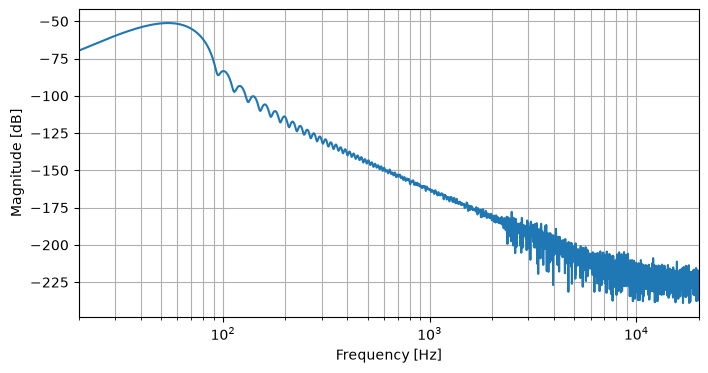

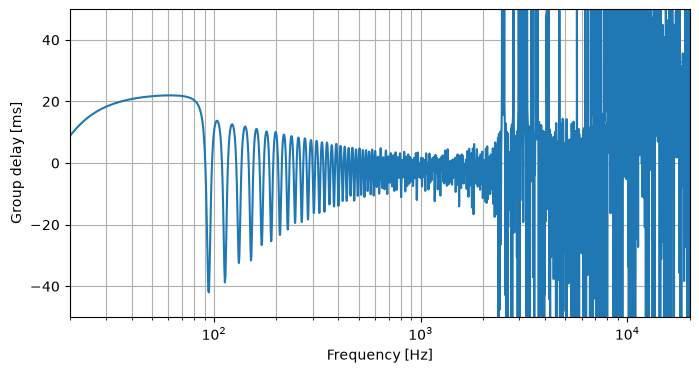

In [29]:
x,y, sr = load_pair(low_sweep)
res = sweep_delay_and_group_delay(x, y, sr)

print(res["delay"])
plot_phase_response(res, gd_ylim=(-10, 20))

In [30]:
h = res["impulse_response"]
peak_sample = res["delay"]["delay_samples"]
t = np.arange(len(h)) / sr

plt.figure(figsize=(10, 4))
plt.plot(t * 1000, h)
plt.axvline(peak_sample / sr * 1000, color="k", linestyle="--")
plt.xlim((peak_sample / sr * 1000) - 10, (peak_sample / sr * 1000) + 100)
plt.xlabel("Time [ms]")
plt.ylabel("Amplitude")
plt.title("Impulse response around detected peak")
plt.grid(True)
plt.show()

NameError: name 'h' is not defined